# Vanilla Neural Network for Affordability Metric


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
df = pd.read_csv('../data/processed/final_3d_df_with_rolling_averages.csv')


In [3]:
lag_features = [col for col in df.columns if 'prev_mo' in col]
rolling_features = [col for col in df.columns if 'rolling' in col]
feature_columns = lag_features + rolling_features
fips_encoded = pd.get_dummies(df['fips'], prefix='fips', drop_first=True)


# Prepare X and y
X_feature = df[feature_columns].values
X = np.column_stack([X_feature, fips_encoded.values])
y = df['Affordability Metric'].values


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
split_year = 2020

train_mask = df['year'] <= split_year
test_mask = df['year'] > split_year


X_train = X_scaled[train_mask.values]
y_train = y[train_mask.values]
X_test = X_scaled[test_mask.values]
y_test = y[test_mask.values]




In [6]:
input_size = X_train.shape[1]

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_size,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

/opt/miniconda3/envs/ArtificialNeuralNetworks/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       101,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,129 (406.75 KB)

 Trainable params: 104,129 (406.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)


Epoch 1/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 1258.2054 - mae: 24.9247 - val_loss: 1097459.2500 - val_mae: 784.3708
Epoch 2/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 891us/step - loss: 12621.0215 - mae: 33.4777 - val_loss: 38600.2461 - val_mae: 131.8022
Epoch 3/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 880us/step - loss: 1255.3302 - mae: 24.0076 - val_loss: 19158.4551 - val_mae: 96.8442
Epoch 4/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 885us/step - loss: 911.8212 - mae: 20.1841 - val_loss: 8713.8955 - val_mae: 66.1926
Epoch 5/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 899us/step - loss: 730.7412 - mae: 18.9617 - val_loss: 8513.4053 - val_mae: 63.3806
Epoch 6/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 858us/step - loss: 685.1397 - mae: 18.4340 - val_loss: 6613.2031 - val_mae: 55.1696
Epoch 7/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 8s 891us/step - loss: 627.1284 - mae: 17.5950 - val_loss: 5816.1016 - val_mae: 51.5610
Epoch 8/100
9198/9198 ━━━━━━━━━━━━━━━━━━━━ 9s 935us/step - loss: 593.7497 - mae:

## Evaluate Model Performance

In [13]:

y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)


train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)


train_mean = np.mean(y_train)
baseline_test_pred = np.full_like(y_test, train_mean)
baseline_mse = mean_squared_error(y_test, baseline_test_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_r2 = r2_score(y_test, baseline_test_pred)


print("Train Set:")
print(f"MSE: {train_mse:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"MAE: {train_mae:.6f}")
print(f"R²: {train_r2:.6f}")

print("Test Set:")
print(f"MSE: {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"MAE: {test_mae:.6f}")
print(f"R²: {test_r2:.6f}")

print("BASELINE (Predict Training Mean)")

print(f"Baseline prediction: {train_mean:.2f}")
print(f"MSE:  {baseline_mse:.6f}")
print(f"RMSE: {baseline_rmse:.6f}")
print(f"MAE:  {baseline_mae:.6f}")
print(f"R²:   {baseline_r2:.6f}")

Train Set:
MSE: 560.398940
RMSE: 23.672747
MAE: 17.976167
R²: 0.740991
Test Set:
MSE: 418.480869
RMSE: 20.456805
MAE: 15.993842
R²: 0.779535
BASELINE (Predict Training Mean)
Baseline prediction: 129.04
MSE:  2422.818839
RMSE: 49.222138
MAE:  39.825834
R²:   -0.276392


## Visualize Training History and Predictions

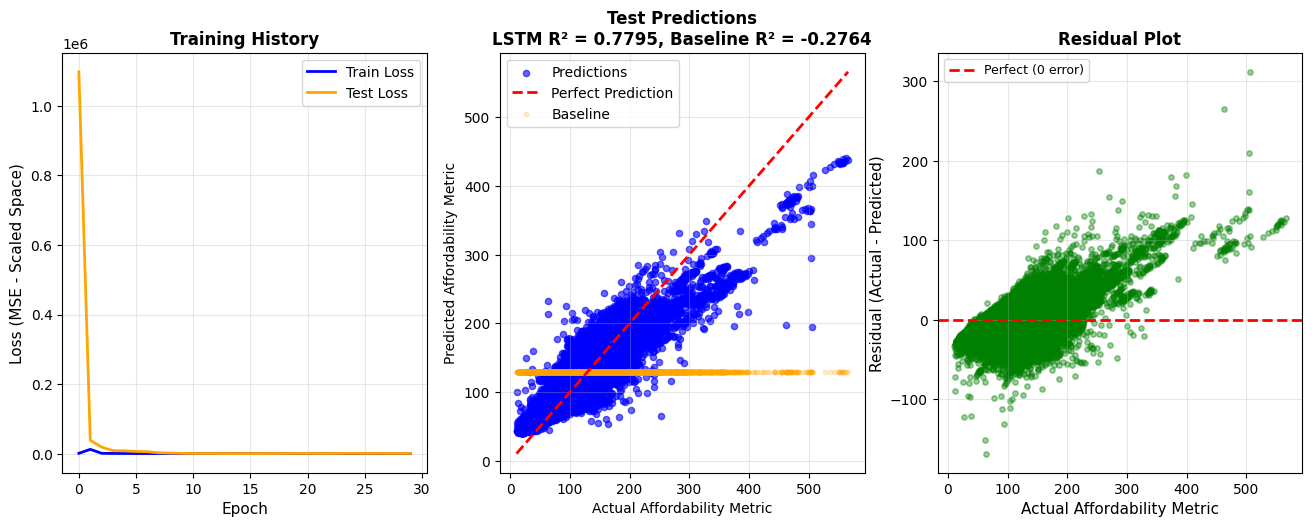

In [15]:
ig = plt.figure(figsize=(16, 12))

# 1. Training Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Test Loss', linewidth=2, color='orange')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (MSE - Scaled Space)', fontsize=11)
ax1.set_title('Training History', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Actual vs Predicted - Scatter Plot
ax2 = plt.subplot(2, 3, 2)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax2.scatter(y_test, y_test_pred, alpha=0.6, s=20, color='blue', label='Predictions')
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax2.scatter(y_test, baseline_test_pred, alpha=0.2, s=10, color='orange', label='Baseline')
ax2.set_xlabel('Actual Affordability Metric')
ax2.set_ylabel('Predicted Affordability Metric')
ax2.set_title(f'Test Predictions\nLSTM R² = {test_r2:.4f}, Baseline R² = {baseline_r2:.4f}', 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Residuals (Errors)
ax3 = plt.subplot(2, 3, 3)
test_residuals = y_test - y_test_pred.ravel()
ax3.scatter(y_test, test_residuals, alpha=0.4, s=15, color='green')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Perfect (0 error)')
ax3.set_xlabel('Actual Affordability Metric', fontsize=11)
ax3.set_ylabel('Residual (Actual - Predicted)', fontsize=11)
ax3.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)